**Aleksander Hański 160315 and Michał Żurawski ??????**

In [26]:
import kagglehub
import shutil
import os

import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

# Loading dataset:

In [27]:
# Download to kaggle cache first
cache_path = kagglehub.dataset_download("abdulmalik1518/cars-datasets-2025")

# Copy to your desired local folder
destination = "./dataset"  # ← change this to your preferred path
os.makedirs(destination, exist_ok=True)
shutil.copytree(cache_path, destination, dirs_exist_ok=True)

print("Files saved to:", destination)
for f in os.listdir(destination):
    print(" -", f)

Files saved to: ./dataset
 - Cars Datasets 2025.csv


In [28]:
df = pd.read_csv("./dataset/Cars Datasets 2025.csv", encoding="cp1252")

df.head

<bound method NDFrame.head of      Company Names         Cars Names                             Engines  \
0          FERRARI      SF90 STRADALE                                  V8   
1      ROLLS ROYCE            PHANTOM                                 V12   
2             Ford                KA+                         1.2L Petrol   
3         MERCEDES            GT 63 S                                  V8   
4             AUDI         AUDI R8 Gt                                 V10   
...            ...                ...                                 ...   
1213        Toyota       Crown Signia                      2.5L Hybrid I4   
1214        Toyota  4Runner (6th Gen)  2.4L Turbo I4 (i-FORCE MAX Hybrid)   
1215        Toyota      Corolla Cross              2.0L Gas / 2.0L Hybrid   
1216        Toyota             C-HR+                   1.8L / 2.0L Hybrid   
1217        Toyota     RAV4 (6th Gen)        2.5L Hybrid / Plug-in Hybrid   

        CC/Battery Capacity    HorsePower Tot

# Dataset preprocessing:

In [29]:
print(df.isnull().sum())

Company Names                0
Cars Names                   0
Engines                      0
CC/Battery Capacity          3
HorsePower                   0
Total Speed                  0
Performance(0 - 100 )KM/H    6
Cars Prices                  0
Fuel Types                   0
Seats                        0
Torque                       1
dtype: int64


In [30]:
df = df.dropna()

In [31]:
for col in df.columns:
    print(f"\n{col} ({df[col].nunique()} unique values) | type: {df[col].dtype}")
    if df[col].nunique() < 20: 
        print(df[col].unique())


Company Names (37 unique values) | type: object

Cars Names (1193 unique values) | type: object

Engines (350 unique values) | type: object

CC/Battery Capacity (309 unique values) | type: object

HorsePower (453 unique values) | type: object

Total Speed (113 unique values) | type: object

Performance(0 - 100 )KM/H (180 unique values) | type: object

Cars Prices (533 unique values) | type: object

Fuel Types (21 unique values) | type: object

Seats (17 unique values) | type: object
['2' '5' '4' '2+2' '7' '8' '12' '3' '9' '6' '1' '2–15' '2–7' '2–6' '7–8'
 '2–9' '2–12']

Torque (262 unique values) | type: object


## Seats:

In [32]:
print(df[df["Seats"].isin(["2+2", "2-6", "2-7","2-9", "2-12", "2-15", "7-8"])])

   Company Names   Cars Names  Engines CC/Battery Capacity HorsePower  \
11       FERRARI    PORTOFINO       V8            3,900 cc     592 hp   
12       FERRARI         ROMA       V8            3,900 cc     612 hp   
15       FERRARI  PORTOFINO M       V8            3,900 cc     612 hp   
16       FERRARI  ROMA SPIDER       V8            3,900 cc     612 hp   
18        TOYOTA    TOYOTA 86  BOXER-4            1,998 cc     205 hp   

   Total Speed Performance(0 - 100 )KM/H Cars Prices Fuel Types Seats  Torque  
11    320 km/h                   3.2 sec   $210,000      Petrol   2+2  760 Nm  
12    320 km/h                   3.4 sec   $230,000      Petrol   2+2  760 Nm  
15    320 km/h                   3.2 sec   $220,000      Petrol   2+2  760 Nm  
16    320 km/h                   3.4 sec   $240,000      Petrol   2+2  760 Nm  
18    226 km/h                   6.4 sec    $27,000      Petrol   2+2  205 Nm  


There are only alternatives with "2+2" seats.

In [33]:
df = df[df["Seats"].isin(['6','7','8','9','12'])]

print(len(df))

198


In [34]:
CRITERIA = {"Seats": ['6','7','8','9','12']}

## Total speed:

In [35]:
print(df["Total Speed"])

20      220 km/h
21      200 km/h
29      225 km/h
132     250 km/h
174     200 km/h
          ...   
1165    185 km/h
1173    210 km/h
1176    160 km/h
1195    185 km/h
1214    180 km/h
Name: Total Speed, Length: 198, dtype: object


In [36]:
df["Total Speed"] = df["Total Speed"].str.replace(" km/h", "").astype(int)
print(df["Total Speed"])

20      220
21      200
29      225
132     250
174     200
       ... 
1165    185
1173    210
1176    160
1195    185
1214    180
Name: Total Speed, Length: 198, dtype: int64


125
262


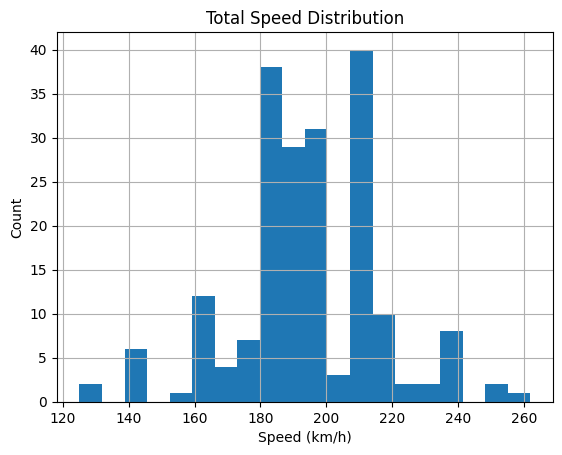

In [37]:
print(df["Total Speed"].min())
print(df["Total Speed"].max())

df["Total Speed"].hist(bins=20)
plt.title("Total Speed Distribution")
plt.xlabel("Speed (km/h)")
plt.ylabel("Count")
plt.show()

In [38]:
levels = np.linspace(df["Total Speed"].min(), df["Total Speed"].max(), 6)
levels

array([125. , 152.4, 179.8, 207.2, 234.6, 262. ])

In [39]:
CRITERIA["Total Speed"] = [f"≥{lvl}" for lvl in levels[:-1]]
print(CRITERIA)

{'Seats': ['6', '7', '8', '9', '12'], 'Total Speed': ['≥125.0', '≥152.4', '≥179.8', '≥207.2', '≥234.6']}


In [40]:
def snap_to_bin_label(value, levels):
    extended = np.append(levels, np.inf)
    idx = np.digitize(value, extended) - 1
    idx = np.clip(idx, 0, len(levels) - 1)
    # use levels[idx] but cap at second-to-last level
    label_idx = min(idx, len(levels) - 2)
    return f"≥{levels[label_idx]}"

df["Total Speed"] = df["Total Speed"].apply(lambda x: snap_to_bin_label(x, levels))
print(df["Total Speed"].unique())

['≥207.2' '≥179.8' '≥234.6' '≥152.4' '≥125.0']


## HorsePower:

In [41]:
print(df["HorsePower"])

20      381 hp
21      381 hp
29      284 hp
132     335 hp
174     247 hp
         ...  
1165    200 hp
1173    250 hp
1176    115 hp
1195    150 hp
1214    326 hp
Name: HorsePower, Length: 198, dtype: object


In [42]:
df["HorsePower"] = (df["HorsePower"]
    .str.replace(" hp", "", case=False)
    .str.replace(",", "")
    .str.strip()
    .str.split(" - ")
    .apply(lambda x: (int(x[0]) + int(x[1])) / 2 if len(x) == 2 else int(x[0]))
)
print(df["HorsePower"])

20      381.0
21      381.0
29      284.0
132     335.0
174     247.0
        ...  
1165    200.0
1173    250.0
1176    115.0
1195    150.0
1214    326.0
Name: HorsePower, Length: 198, dtype: float64


85.0
1020.0


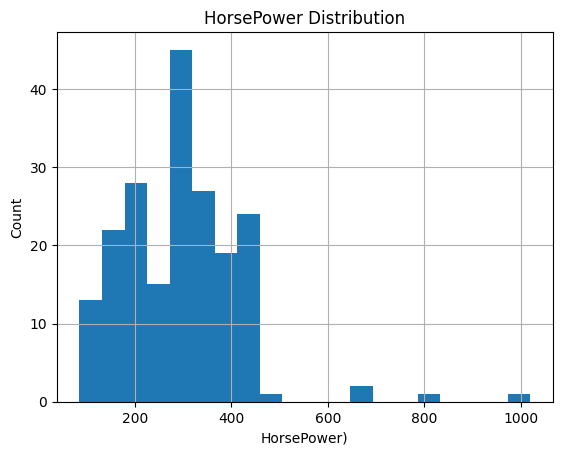

In [43]:
print(df["HorsePower"].min())
print(df["HorsePower"].max())

df["HorsePower"].hist(bins=20)
plt.title("HorsePower Distribution")
plt.xlabel("HorsePower)")
plt.ylabel("Count")
plt.show()

In [44]:
levels = np.linspace(df["HorsePower"].min(), df["HorsePower"].max(), 6)
levels

CRITERIA["HorsePower"] = [f"≥{lvl}" for lvl in levels[:-1]]
print(CRITERIA)

df["HorsePower"] = df["HorsePower"].apply(lambda x: snap_to_bin_label(x, levels))
print(df["HorsePower"].unique())

{'Seats': ['6', '7', '8', '9', '12'], 'Total Speed': ['≥125.0', '≥152.4', '≥179.8', '≥207.2', '≥234.6'], 'HorsePower': ['≥85.0', '≥272.0', '≥459.0', '≥646.0', '≥833.0']}
['≥272.0' '≥85.0' '≥646.0' '≥833.0' '≥459.0']


need to change it so that we have more bins within guys not being outliers

## Price:

In [45]:
print(df["Cars Prices"])

20               $85,000 
21               $50,000 
29               $35,000 
132              $60,000 
174              $60,000 
              ...        
1165    $25,000 - $30,000
1173    $45,000 - $50,000
1176    $20,000 - $24,000
1195    $22,000 - $26,000
1214             $50,000 
Name: Cars Prices, Length: 198, dtype: object


In [46]:
df["Cars Prices"] = (df["Cars Prices"]
    .str.replace("$", "", regex=False)
    .str.replace(",", "")
    .str.strip()
    .str.split(" - ")
    .apply(lambda x: (int(x[0]) + int(x[1])) / 2 if len(x) == 2 else int(x[0]))
)
print(df["Cars Prices"])

20      85000.0
21      50000.0
29      35000.0
132     60000.0
174     60000.0
         ...   
1165    27500.0
1173    47500.0
1176    22000.0
1195    24000.0
1214    50000.0
Name: Cars Prices, Length: 198, dtype: float64


15000.0
149990.0


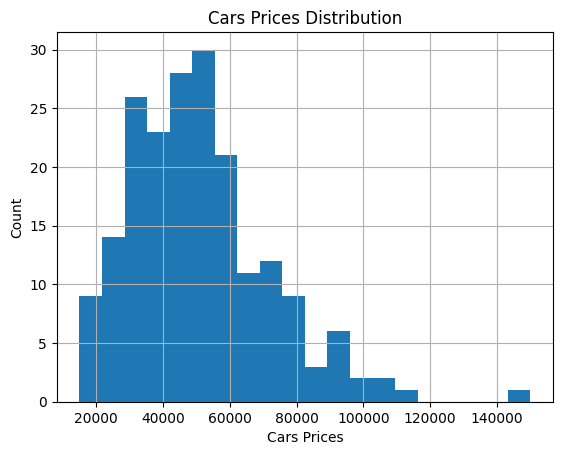

In [47]:
print(df["Cars Prices"].min())
print(df["Cars Prices"].max())

df["Cars Prices"].hist(bins=20)
plt.title("Cars Prices Distribution")
plt.xlabel("Cars Prices")
plt.ylabel("Count")
plt.show()

In [48]:
levels = np.linspace(df["Cars Prices"].max(), df["Cars Prices"].min(), 6)

levels_sorted = np.sort(levels)  # ascending for digitize
levels_desc = levels             # descending for labels (best → worst)

CRITERIA["Cars Prices"] = [f"≤{lvl}" for lvl in levels_desc[:-1]]

def snap_to_bin_label_cost(value, levels_asc, levels_desc):
    extended = np.append(levels_asc, np.inf)
    idx = np.digitize(value, extended) - 1
    idx = np.clip(idx, 0, len(levels_asc) - 2)
    # invert index so cheap = high bin
    inv_idx = len(levels_desc) - 2 - idx
    return f"≤{levels_desc[inv_idx]}"

df["Cars Prices"] = df["Cars Prices"].apply(
    lambda x: snap_to_bin_label_cost(x, levels_sorted, levels_desc)
)
print(df["Cars Prices"].unique())

['≤95994.0' '≤68996.0' '≤41998.0' '≤122992.0' '≤149990.0']


# UTA:

In [49]:
print(CRITERIA)

{'Seats': ['6', '7', '8', '9', '12'], 'Total Speed': ['≥125.0', '≥152.4', '≥179.8', '≥207.2', '≥234.6'], 'HorsePower': ['≥85.0', '≥272.0', '≥459.0', '≥646.0', '≥833.0'], 'Cars Prices': ['≤149990.0', '≤122992.0', '≤95994.0', '≤68996.0', '≤41998.0']}
